# Cowan & Agol (2008) and Lambertian phase curve models fitting with CHEOPS data

This notebook will demonstrate how we can fit two types of phase curve models to the data: 1) a models from [Cowan & Agol (2008)](https://ui.adsabs.harvard.edu/abs/2008ApJ...678L.129C/abstract), and 2) a Lamebertian model. 

We will use the [Cowan & Agol (2008)](https://ui.adsabs.harvard.edu/abs/2008ApJ...678L.129C/abstract)'s phase curve model as implemented by [Kempton et al. (2023)](https://ui.adsabs.harvard.edu/abs/2023Natur.620...67K/abstract). The model is defined as,

$$\frac{F_p}{F_\star} = E + C_1 (\cos{\omega_p t_e} - 1) + D_1\sin{\omega_p t_e} + C_2 (\cos{2\omega_p t_e} - 1) + D_2\sin{2\omega_p t_e}.$$

Here, $E$, $C_1$, $D_1$, $C_2$, and $D_2$ are phase curve coefficients, $t_e$ is the time since mid-occultation and $\omega_p = 2\pi/P$, where $P$ is the orbital period of the planet. Being a sinusoidal model, it is a versatile model which can fit many complex shapes quite easily. At the occultation time, i.e., $t_e=0$, $F_p = E$, which would be the occultation depth (i.e., dayside emission). Similarly, at the transit time, $t_e = \pm P/2$, $F_p = E - 2C_1$, giving the nightside emission from the planet. We can ignore the second order terms ($C_2$ and $D_2$) and use a simplistic first order model. Since the first-order model (i.e., $C_2=D_2=0$) is a nested model of the second order model (non zero $C_2$ and $D_2$), we can use the Bayesian evidence to select the optimal order to fit the data.

One of the advantages of using [Cowan & Agol (2008)](https://ui.adsabs.harvard.edu/abs/2008ApJ...678L.129C/abstract) phase curve model is that we can invert this model to find the intensity map of the planet. The intensity map can finally be used to construct a temperature map of the planet as we will show below.

Another useful phase curve model is reflectance from a perfect Lambertian sphere, that is, isotropically scattering sphere. We will use the formulation by [Deline et al. (2022)](https://ui.adsabs.harvard.edu/abs/2022A%26A...659A..74D/abstract) for this model:

$$\frac{F_p}{F_\star} = A_g \left( \frac{R_p}{a} \frac{1 + e\cos{\nu}}{1-e^2} \right)^2 \frac{\sin{\alpha} + (\pi - \alpha)\cos{\alpha}}{\pi}$$

This model is parametrised by only one parameter, $A_g$, geometric albedo of the planet's dayside, all other parameters are planetary orbital parameters. $a$, $R_p$, $e$, and $\nu$ are semi-major axis, planetary radius, eccentricity, and true anomaly, respectively. Finally, $\alpha = \arccos{\left[ -\sin{(\omega + \nu)} \cdot \sin{i_p} \right]}$, where $\omega$ and $i_p$ are the argument of peri-astron and orbital inclination, respectively.

We will first demonstrate the usage of [Cowan & Agol (2008)](https://ui.adsabs.harvard.edu/abs/2008ApJ...678L.129C/abstract) model, and then discuss the Lambertian model towards the end of the notebook. We will use CHEOPS observations of an ultra-hot Jupiter WASP-189 b for this purpose: the observations, published in [Deline et al. (2022)](https://ui.adsabs.harvard.edu/abs/2022A%26A...659A..74D/abstract) and [Patel et al. (2025)](https://ui.adsabs.harvard.edu/abs/2025arXiv251205175P/abstract), contain four occultations (with visit numbers CHEOPS201, CHEOPS202, CHEOPS203, and CHEOPS204) and two full phase curves (CHEOPS701 and CHEOPS702). Let's begin by loading all the necessary packages.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gd
from scipy.ndimage import median_filter
import seaborn as sns
from utils import pipe_data
from astropy.stats import mad_std
import plotstyles
import corner
import juliet
import os

## I have MacBook Pro with M1 chip, so I need following two lines for multiprocessing to work
import multiprocessing
multiprocessing.set_start_method('fork')

print('juliet version:', juliet.__version__)

juliet version: 2.2.9


We will need some planetary parameters, which we take from the literature. We will also define a function that can standardise any vector.

In [2]:
# And priros
## We need planetary and stellar parameters for this (all parameters are from Anderson et al. 2018)
per, per_err = 2.7240330, 0.0000042             # Orbital period in days
t0, t0_err =  2456706.4545, 0.0018              # Transit epoch in BJD
b, b_err = 0.4537, 0.0072                       # Impact parameter
rho, rho_err = 216.47, 16.16                    # Stellar density in kg/m3

# To standardise any vector
def standard(x):
    return ( x - np.median(x) ) / mad_std( x )

Our next task is to load CHEOPS data. We will use the photometric data reduced by [PIPE](https://github.com/alphapsa/PIPE) package, which I already put in the 'Data/PIPE' folder. I have also written a function, called `pipe_data` in `utils.py` to extract photometric data from those fits files. In particular, the function masks all data points with high background (higher than 400 e-/s) and normalise the light curves. The code can be a bit messy so I put everything in the function. The function put all data in a dictionary with self-explanatory keys. Let's load and plot the light curves.

We will also save all data in dictionaries in way that `juliet` understands.

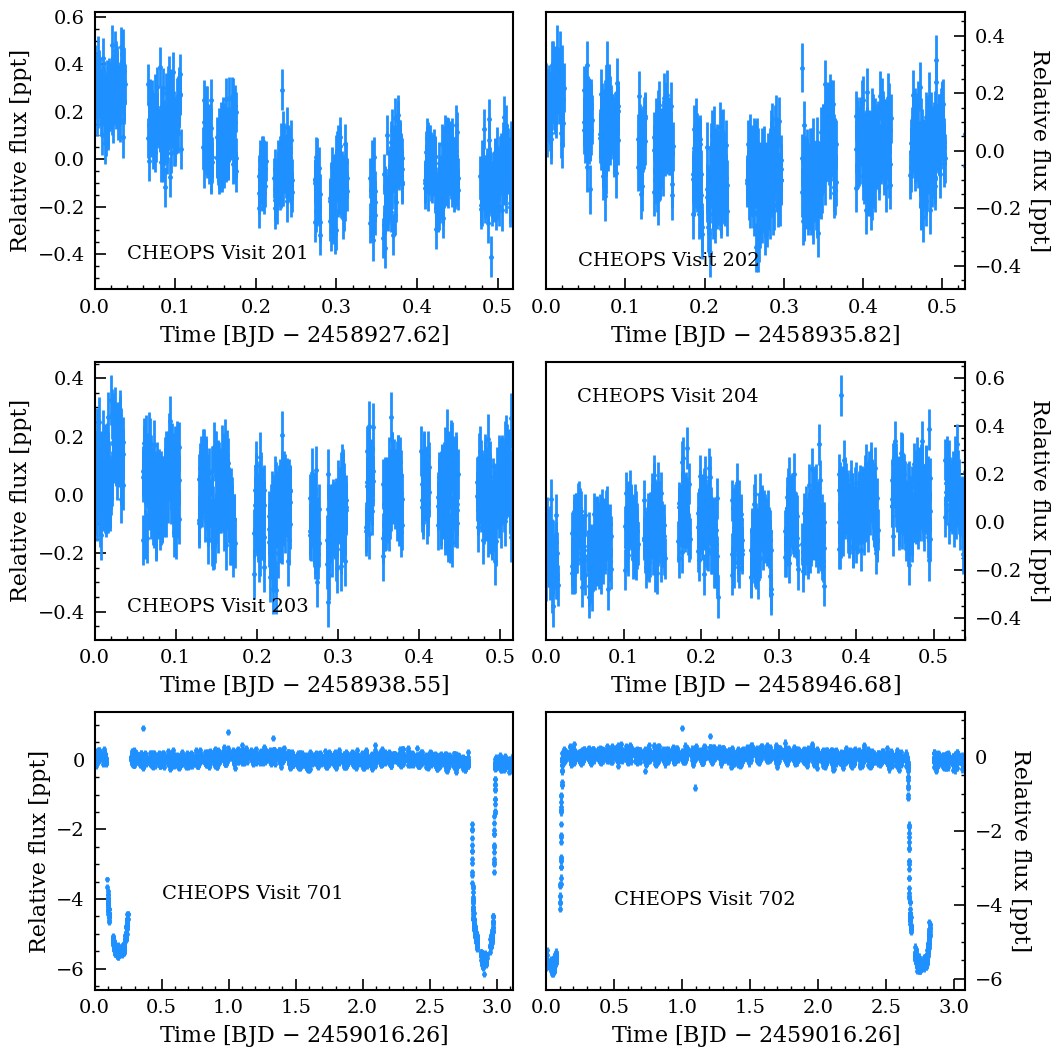

In [3]:
# Instruments
instruments = ['CHEOPS201', 'CHEOPS202', 'CHEOPS203', 'CHEOPS204', 'CHEOPS701', 'CHEOPS702']

# Loading the data
tim, fl, fle = {}, {}, {}
data_dicts = []
for ins in range(len(instruments)):
    ## Loading the data from fits files
    d1 = pipe_data(os.getcwd() + '/Data/PIPE/WASP-189_' + instruments[ins][6:] + '_sa.fits', bgmin=400)
    ## Saving the light curve data in dicts
    tim[instruments[ins]], fl[instruments[ins]], fle[instruments[ins]] = d1['TIME'], d1['FLUX'], d1['FLUX_ERR']

    ## Saving also the data dicts so that we can access the rest of the data products later
    data_dicts.append(d1)


# Ploting the data
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(16/1.5, 16/1.5))
axs[0, 0].errorbar(tim['CHEOPS201']-tim['CHEOPS201'][0], ( fl['CHEOPS201'] - 1. )*1e3, yerr=fle['CHEOPS201']*1e3, fmt='.', color='dodgerblue' )
axs[0, 0].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim['CHEOPS201'][0]))
axs[0, 0].set_ylabel('Relative flux [ppt]')
axs[0, 0].text(0.04, -0.42, 'CHEOPS Visit 201', fontsize=14, color='k')
axs[0, 0].set_xlim([0., np.max(tim['CHEOPS201']-tim['CHEOPS201'][0])])

axs[0, 1].errorbar(tim['CHEOPS202']-tim['CHEOPS202'][0], ( fl['CHEOPS202'] - 1. )*1e3, yerr=fle['CHEOPS202']*1e3, fmt='.', color='dodgerblue' )
axs[0, 1].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim['CHEOPS202'][0]))
axs[0, 1].set_ylabel('Relative flux [ppt]', rotation=270, labelpad=20)
axs[0, 1].text(0.04, -0.4, 'CHEOPS Visit 202', fontsize=14, color='k')
axs[0, 1].set_xlim([0., np.max(tim['CHEOPS202']-tim['CHEOPS202'][0])])
axs[0, 1].yaxis.tick_right()
axs[0, 1].yaxis.set_label_position('right')

axs[1, 0].errorbar(tim['CHEOPS203']-tim['CHEOPS203'][0], ( fl['CHEOPS203'] - 1. )*1e3, yerr=fle['CHEOPS203']*1e3, fmt='.', color='dodgerblue' )
axs[1, 0].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim['CHEOPS203'][0]))
axs[1, 0].set_ylabel('Relative flux [ppt]')
axs[1, 0].text(0.04, -0.4, 'CHEOPS Visit 203', fontsize=14, color='k')
axs[1, 0].set_xlim([0., np.max(tim['CHEOPS203']-tim['CHEOPS203'][0])])

axs[1, 1].errorbar(tim['CHEOPS204']-tim['CHEOPS204'][0], ( fl['CHEOPS204'] - 1. )*1e3, yerr=fle['CHEOPS204']*1e3, fmt='.', color='dodgerblue' )
axs[1, 1].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim['CHEOPS204'][0]))
axs[1, 1].set_ylabel('Relative flux [ppt]', rotation=270, labelpad=20)
axs[1, 1].text(0.04, 0.5, 'CHEOPS Visit 204', fontsize=14, color='k')
axs[1, 1].set_xlim([0., np.max(tim['CHEOPS204']-tim['CHEOPS204'][0])])

axs[1, 1].yaxis.tick_right()
axs[1, 1].yaxis.set_label_position('right')


axs[2, 0].errorbar(tim['CHEOPS701']-tim['CHEOPS701'][0], ( fl['CHEOPS701'] - 1. )*1e3, yerr=fle['CHEOPS701']*1e3, fmt='.', color='dodgerblue' )
axs[2, 0].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim['CHEOPS701'][0]))
axs[2, 0].set_ylabel('Relative flux [ppt]')
axs[2, 0].text(0.5, -4., 'CHEOPS Visit 701', fontsize=14, color='k')
axs[2, 0].set_xlim([0., np.max(tim['CHEOPS701']-tim['CHEOPS701'][0])])

axs[2, 1].errorbar(tim['CHEOPS702']-tim['CHEOPS702'][0], ( fl['CHEOPS702'] - 1. )*1e3, yerr=fle['CHEOPS702']*1e3, fmt='.', color='dodgerblue' )
axs[2, 1].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim['CHEOPS701'][0]))
axs[2, 1].set_ylabel('Relative flux [ppt]', rotation=270, labelpad=20)
axs[2, 1].text(0.5, -4., 'CHEOPS Visit 702', fontsize=14, color='k')
axs[2, 1].set_xlim([0., np.max(tim['CHEOPS702']-tim['CHEOPS702'][0])])

axs[2, 1].yaxis.tick_right()
axs[2, 1].yaxis.set_label_position('right')

plt.tight_layout()

Okay, so we have 6 observations, four of them are occultations and two of them are full phase curves. It can be clearly seen that there is a lots of correlated noise in the data. Most of the noise is coming from the instrument: during any observations the CHEOPS field of view rotates around the target, which creates strong correlations with the roll angle. This roll angle modulations are one of the main sources of the instrumental noise in CHEOPS observations. For example, below we show how the flux changes with the roll angle in CHEOPS visit 202:

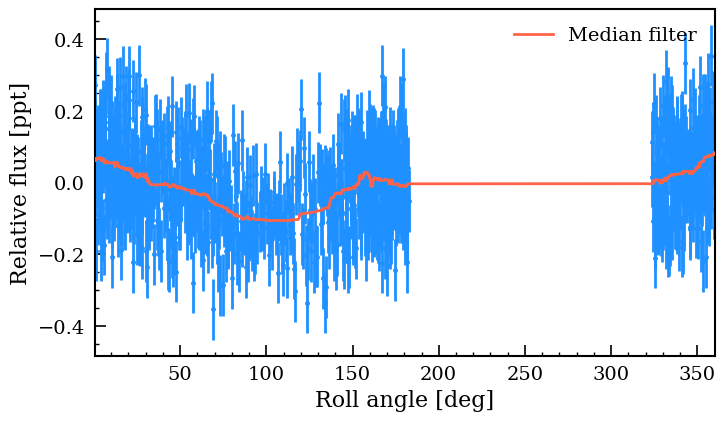

In [4]:
idx = np.argsort(data_dicts[1]['ROLL'])

fig, axs = plt.subplots(figsize=(16/2, 9/2))
axs.errorbar(data_dicts[1]['ROLL'], (data_dicts[1]['FLUX']-1.)*1e3, yerr=data_dicts[1]['FLUX_ERR']*1e3, fmt='.', color='dodgerblue')
axs.plot(data_dicts[1]['ROLL'][idx], median_filter((data_dicts[1]['FLUX'][idx]-1.)*1e3, size=100), color='tomato', zorder=10, label='Median filter')

axs.set_xlabel('Roll angle [deg]')
axs.set_ylabel('Relative flux [ppt]')

axs.set_xlim([np.min(data_dicts[1]['ROLL']), np.max(data_dicts[1]['ROLL'])])

axs.legend()

There is a clear trend of flux with the roll angle as can be seen from the figure above. The amplitude of this trend is on the order of 0.1 ppt (= 100 ppm), which is roughly the same order of magnitude as the occultation signal. So, we need to carefully model this trend in order to recover the occultation properly. Following [Deline et al. (2022)](https://ui.adsabs.harvard.edu/abs/2022A%26A...659A..74D/abstract), we will use the following sinusoidal model, with up to first five harmonics, to detrend this noise:

$$ \text{Roll angle trend} = \sum_{i=1}^5 \left[ a_i \sin{(i\cdot \text{RA})} + b_i \cos{(i\cdot \text{RA})} \right] $$

Here, $\text{RA}$ is the roll angle and $(a_i, b_i)$ are the coefficients of the model. We will try to constrain the values of $(a_i, b_i)$ in our fitting process. We will fit one such model for all occultation observations (i.e., CHEOPS visits 201, 202, 203, and 204), and another similar model for phase curve observations (i.e., CHEOPS visits 701 and 702; see [Deline et al. 2022](https://ui.adsabs.harvard.edu/abs/2022A%26A...659A..74D/abstract) for details). This means that, we will have to fit two sets of $(a_i^{occ}, b_i^{occ})$ and $(a_i^{pc}, b_i^{pc})$ coefficients, one for occultations, and another for phase curves. 

This is easy to do in `juliet` -- we can simply add above function as a linear model in `juliet` fit. $\sin{(i\cdot RA)}$ and $\cos{(i\cdot RA)}$, with $i=1$ to $5$, will be our regressors (i.e., 10 regressors per observation). Since we want to fit the same roll angle trend for all occultation observations, we will share $(a_i^{occ}, b_i^{occ})$ for _all_ occultation observations (i.e., CHEOPS visits 201, 202, 203, and 204). In `juliet`'s language, we will share the `thetaN` parameters corresponding to $\sin{(i\cdot RA)}$ and $\cos{(i\cdot RA)}$ regressors for CHEOPS visits 201 to 204. We will repeat the same thing for two phase curve observations, CHEOPS visits 701 and 702. This sinusoidal model alone would add 20 free parameters for all observations.

Unfortunately, the roll angle trend is not the only source of correlated noise in the data. Another well-known instrumental noise is the ramp effect, which is correlated with the $\text{thermFront\_2}$ sensor data. We have the data from $\text{thermFront\_2}$ sensor for all of our observations, which we include as linear regressor in our model. Finally, each observation seems to have an overall long-term trend with time: while this trend is readily observable in CHEOPS visits 202 and 203, it is also present in other observations. We will model this trend with up to quadratic and linear model in time for occultation and phase curve observations, respectively.

[Deline et al. (2022)](https://ui.adsabs.harvard.edu/abs/2022A%26A...659A..74D/abstract) showed that there is an additional stellar noise present in the phase curve observations. We will use Gaussian process ((GP)) model, with simple harmonic oscillator (SHO) kernel, to take care of this stellar noise.

We will now generate linear and GP regressors for each instrument and save them in dictionaries so that we can ingest them to `juliet`.

In [5]:
# Dictionaries for saving GP and linear regressors
gp_pars, lin_pars = {}, {}

for ins in range(len(data_dicts)):
    # Loading the data
    d1 = data_dicts[ins]

    # Linear regressors for roll angle modulation
    ## First, extracting roll angle
    roll = np.radians(d1['ROLL'])
    ## Saving sin(i*roll_angle) and cos(i*roll_angle) for i=1, 2, 3, 4, and 5
    ## Also putting thermFront2 sensor data (it is named as TF2), and linear regressor in time
    lins1 = np.vstack([ np.sin(roll), np.sin(2*roll), np.sin(3*roll), np.sin(4*roll), np.sin(5*roll),\
                        np.cos(roll), np.cos(2*roll), np.cos(3*roll), np.cos(4*roll), np.cos(5*roll),\
                        standard(d1['TF2']), d1['TIME'] - np.mean(d1['TIME']) ])
    
    if instruments[ins][0:7] == 'CHEOPS2':
        # Occultation only data
        ## For occultation, we also want quadratic term in temporal trend
        lins1 = np.vstack([ lins1, (d1['TIME'] - np.mean(d1['TIME']))**2 ])
    
    if instruments[ins][0:7] == 'CHEOPS7':
        # Phase curve only data
        ## For phase curves, we want a GP model in time, so setting GP regressors
        gp_pars[instruments[ins]] = d1['TIME']
    
    lin_pars[instruments[ins]] = np.transpose( lins1 )

Now, we have almost everything, so now we want to design priors. In addition to the usual priors, we wil need extra priors for our phase curve model.

- [Cowan & Agol (2008)](https://ui.adsabs.harvard.edu/abs/2008ApJ...678L.129C/abstract) phase curve model needs five parameters to use it: `fp_p1`, `C1_p1`, `D1_p1`, `C2_p1`, and `D2_p1`. They are defined in the first equation in the current notebook ($E$ from Eq. 1 is `fp_p1`). All of these parameters are planetary _and_ instrumental parameters, i.e., we can share these parameters over multiple instruments. The usual terminology is that we first write planet's name, and then instrument's name, like `C1_p1_instrument`, etc.

- We will use the first order [Cowan & Agol (2008)](https://ui.adsabs.harvard.edu/abs/2008ApJ...678L.129C/abstract) phase curve function, so we will fix `C2_p1` and `D2_p1` to 0. while providing priors. For other parameters, we will provide wide uniform priors.

- Since there are transits in two CHEOPS visits, visit 701 and 702, we will add limb-darkening coefficients for both of these visits to enable transit model. We will thus provide limb darkening coefficients, `q1` and `q2` for instruments CHEOPS701 and CHEOPS701.

- We need to provide priors on `theta` coefficients of the linear model. We need to remember the order and total number of free parameters for each instruments (I mean we will provide uniform priors for each of these `theta` parameter, so the order might not matter that much, but the total number definitely does.).

- Finally, we will provide priors on GP hyperparameters. We will use simple harmonic oscillator (SHO) kernel to generate a GP model, which requires three free parameters.

In [6]:
### Predicting transit and occultation time for our observations
cycle = round((tim['CHEOPS702'][-1] - t0) / per)
tc, tc_err = t0 + cycle*per, np.sqrt(t0_err**2 + (cycle*per_err)**2)
tsec, tsec_err = tc + (per/2), np.sqrt(tc_err**2 + per_err**2)

# Designing priors
## Planetary parameters
par_P = ['P_p1', 't0_p1', 'p_p1', 'b_p1', 'q1_CHEOPS701_CHEOPS702', 'q2_CHEOPS701_CHEOPS702', 'rho', 'ecc_p1', 'omega_p1']
dist_P = ['normal', 'normal', 'uniform', 'normal', 'uniform', 'uniform', 'normal', 'fixed', 'fixed']
hyper_P = [[per, per_err], [tc, tc_err], [0., 1.], [b, 3*b_err], [0., 1.], [0., 1.], [rho, rho_err], 0., 90.]
## Phase curve parameters
par_pc = ['fp_p1', 'C1_p1', 'D1_p1', 'C2_p1', 'D2_p1']
dist_pc = ['uniform', 'uniform', 'uniform', 'fixed', 'fixed']
hyper_pc = [[0., 200.e-6], [-1., 1.], [-1., 1.], 0., 0.]

## Instrumental parameters
par_ins, dist_ins, hyper_ins = [], [], []
for ins in range(len(instruments)):
    par_ins = par_ins + ['mdilution_' + instruments[ins], 'mflux_' + instruments[ins], 'sigma_w_' + instruments[ins]]
    dist_ins = dist_ins + ['fixed', 'normal', 'loguniform']
    hyper_ins = hyper_ins + [1.0, [0., 0.1], [0.1, 10000]]

## Linear model parameters
### First 10 theta are for roll angle model + 2 are for thermFront2 and linear in time + 1 for quadratic in time only for occultations
par_lin = ['theta' + str(i) + '_CHEOPS201_CHEOPS202_CHEOPS203_CHEOPS204' for i in range(10)] +\
    ['theta10_CHEOPS201', 'theta11_CHEOPS201', 'theta12_CHEOPS201', 'theta10_CHEOPS202', 'theta11_CHEOPS202', 'theta12_CHEOPS202',\
     'theta10_CHEOPS203', 'theta11_CHEOPS203', 'theta12_CHEOPS203', 'theta10_CHEOPS204', 'theta11_CHEOPS204', 'theta12_CHEOPS204'] +\
    ['theta' + str(i) + '_CHEOPS701_CHEOPS702' for i in range(10)] + \
    ['theta10_CHEOPS701', 'theta11_CHEOPS701', 'theta10_CHEOPS702', 'theta11_CHEOPS702']
dist_lin = ['uniform'] * len(par_lin)
hyper_lin = [[-1., 1.]] * len(par_lin)

## GP priors
par_gp = ['GP_S0_CHEOPS701_CHEOPS702', 'GP_omega0_CHEOPS701_CHEOPS702', 'GP_Q_CHEOPS701_CHEOPS702']
dist_gp = ['uniform', 'uniform', 'fixed']
hyper_gp = [[np.exp(-30.), np.exp(-15.)], [2*np.pi/10, 2*np.pi/0.1], 1/np.sqrt(2)]

# Total priors
par_tot = par_P + par_pc + par_ins + par_lin + par_gp
dist_tot = dist_P + dist_pc + dist_ins + dist_lin + dist_gp
hyper_tot = hyper_P + hyper_pc + hyper_ins + hyper_lin + hyper_gp

priors = juliet.utils.generate_priors(params=par_tot, dists=dist_tot, hyperps=hyper_tot)

And, now `juliet` fitting. Note that we will not fit for occultation time, but rather calculate the occultation time self-consistently within `juliet`. We need to set `light_travel_delay=True` and provide `stellar_radius` in `juliet.fit` in order to do this.

**Please note that this fitting can take several hours to finish.**

In [7]:
# Output folder
pout = os.getcwd() + '/Analysis/CA08'

# Juliet fitting
data = juliet.load(priors=priors, t_lc=tim, y_lc=fl, yerr_lc=fle,\
                   GP_regressors_lc=gp_pars, linear_regressors_lc=lin_pars, out_folder=pout)
res = data.fit(sampler='dynamic_dynesty', nthreads=8, light_travel_delay=True, stellar_radius=2.365)

Detected dynamic_dynesty sampler output files --- extracting from /Users/jaspa/Documents/Codes/juliet-examples/Analysis/CA08/_dynesty_DNS_posteriors.pkl


Alright! Now that we have finished, we want to plot our results. We need to calculate models (full model, planet-only model) and drended data for that. Let's first do this:

In [8]:
# Let's create dicts to save all models and data for each instruments
## For full models
full_models_all_ins, rand_models_all_ins = {}, {}
## Detrended and binned data
detrended_phs_all_ins, detrended_data_all_ins, detrended_errs_all_ins = {}, {}, {}
### Detrended models
detrended_models_all_ins, detrended_rand_models_all_ins = {}, {}
## Residuals
resid_all_ins = {}

# Planetary parameters
P_post = np.nanmedian( res.posteriors['posterior_samples']['P_p1'] )
tc_post = np.nanmedian( res.posteriors['posterior_samples']['t0_p1'] )

for ins in range(len(instruments)):
    instrument = instruments[ins]
    print('Working on ' + str(instrument) + '...')
    # --------------------------------------------
    #    Some planetary models
    # --------------------------------------------
    ## Mflux and sigma_w (white noise)
    mflx = res.posteriors['posterior_samples']['mflux_' + instrument]
    sigw = np.nanmedian(res.posteriors['posterior_samples']['sigma_w_' + instrument] * 1e-6)

    # --------------------------------------------
    #    Extracting all models
    # --------------------------------------------
    # Creating all models
    model = res.lc.evaluate(instrument, nsamples=5000, return_err=True, return_components=True, return_samples=True)
    ## Saving all models
    all_models = res.lc.model[instrument]

    # --------------------------------------------
    #    Full fitted models
    # --------------------------------------------
    # Full fitted model:
    full_models_all_ins[instrument] = model[1]
    ## Sample random full model (to show uncertainties)
    sample_models = model[0]
    idx_nsamps = np.random.choice( np.arange(sample_models.shape[0]), size=100, replace=False)
    rand_models_all_ins[instrument] = sample_models[idx_nsamps, :]

    # --------------------------------------------
    #    Residuals
    # --------------------------------------------
    resid_all_ins[instrument] = fl[instrument]-model[1]

    # --------------------------------------------
    #    Detrended data
    # --------------------------------------------
    ## GP model
    try:
        gp_median_model = all_models['GP']
    except:
        gp_median_model = np.zeros(len(tim[instrument]))

    ## Linear model
    try:
        lin_median_model = model[-1]['lm']
    except:
        lin_median_model = np.zeros( len( tim[instrument] ) )

    ## F1 and F2 factors (F2=0 for this case since mdilution is fixed to 1)
    ## See, juliet paper to find their meanings
    F1 = np.nanmedian( 1 / ( 1 + mflx ) )
    F2 = 0.

    # Orbital phases
    phases = juliet.utils.get_phases(t=tim[instrument], P=P_post, t0=tc_post, phmin=0.8)
    ## Sorting indices according to orbital phases
    idx_phs = np.argsort(phases)
    detrended_phs_all_ins[instrument] = phases[idx_phs]

    # Detrended data and errors
    detrended_data_all_ins[instrument] = ( ( fl[instrument] - gp_median_model - lin_median_model ) / F1 )[idx_phs]
    detrended_errs_all_ins[instrument] = ( np.sqrt( fle[instrument]**2 + sigw**2 ) )[idx_phs]

    # --------------------------------------------
    #    Detrended models
    # --------------------------------------------
    # Detrended model (we only want to see changes due to planetary parameters so we will fix other params)
    post_samps_new = res.posteriors['posterior_samples'].copy()
    for i in post_samps_new.keys():
        if ( i[0:5] == 'mflux' ) or ( i[0:9] == 'mdilution' ) or ( i[0:5] == 'theta' ) or ( i[0:2] == 'GP' ):
            post_samps_new[i] = np.zeros(len(post_samps_new[i]))

    planet_only_models = res.lc.evaluate(instrument, nsamples=5000, return_err=True, parameter_values=post_samps_new,\
                                         return_components=True, return_samples=True, evaluate_transit=True)

    # Detrended median model
    detrended_models_all_ins[instrument] = planet_only_models[1][idx_phs]
    ## Random models to show uncertainties
    sample_pl_models = planet_only_models[0][:, idx_phs]
    idx_nsamps_pl = np.random.choice( np.arange(sample_pl_models.shape[0]), size=100, replace=False)
    detrended_rand_models_all_ins[instrument] = sample_pl_models[idx_nsamps_pl, :]

    print('Done!!')

Working on CHEOPS201...
Done!!
Working on CHEOPS202...
Done!!
Working on CHEOPS203...
Done!!
Working on CHEOPS204...
Done!!
Working on CHEOPS701...
Done!!
Working on CHEOPS702...
Done!!


Let's first plot the full model fitted to the data:

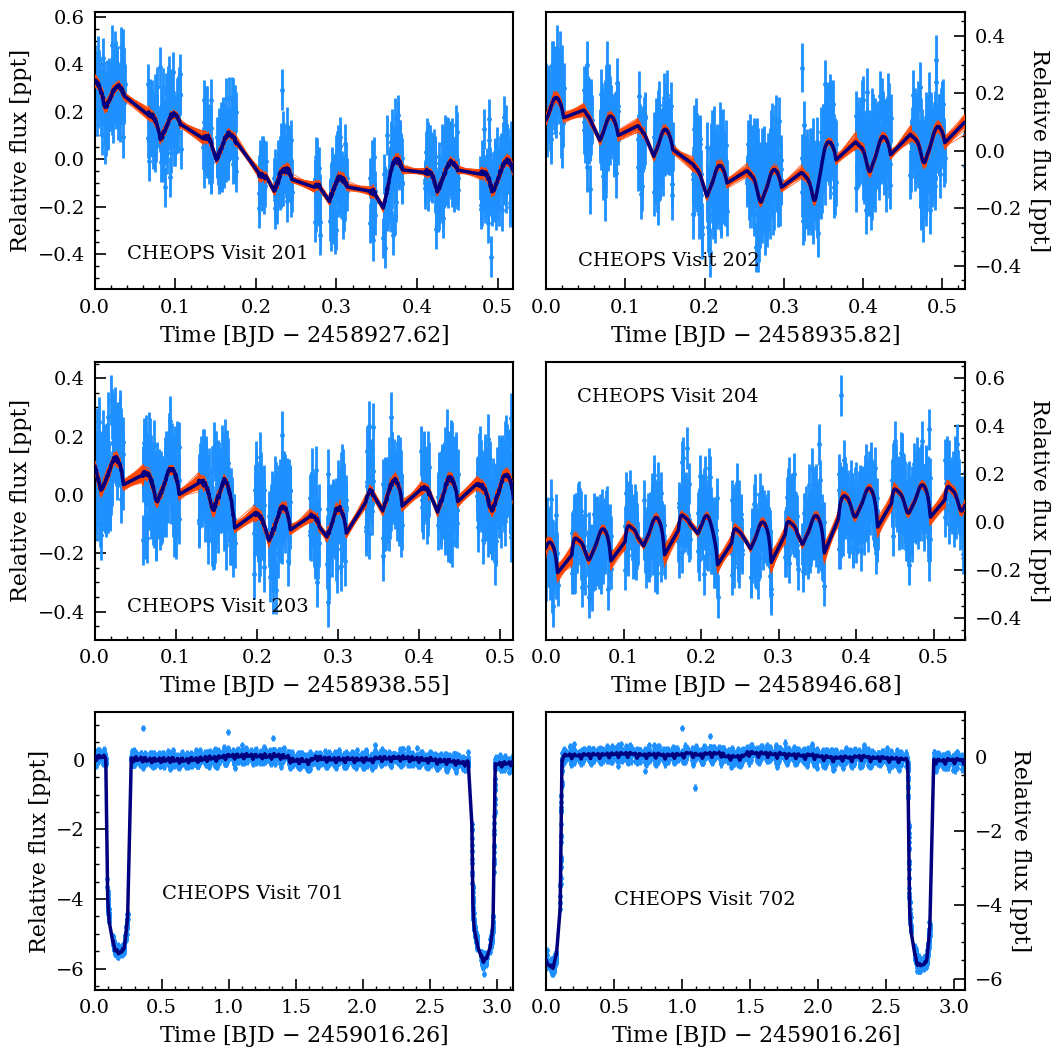

In [9]:
# Ploting the data
## Visit 201
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(16/1.5, 16/1.5))
axs[0, 0].errorbar(tim['CHEOPS201']-tim['CHEOPS201'][0], ( fl['CHEOPS201'] - 1. )*1e3, yerr=fle['CHEOPS201']*1e3, fmt='.', color='dodgerblue' )
axs[0, 0].plot(tim['CHEOPS201']-tim['CHEOPS201'][0], (full_models_all_ins['CHEOPS201'] - 1.)*1e3, color='navy', lw=2.5, zorder=50)
for rand in range(100):
    axs[0, 0].plot(tim['CHEOPS201']-tim['CHEOPS201'][0], (rand_models_all_ins['CHEOPS201'][rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)
axs[0, 0].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim['CHEOPS201'][0]))
axs[0, 0].set_ylabel('Relative flux [ppt]')
axs[0, 0].text(0.04, -0.42, 'CHEOPS Visit 201', fontsize=14, color='k')
axs[0, 0].set_xlim([0., np.max(tim['CHEOPS201']-tim['CHEOPS201'][0])])

## Visit 202
axs[0, 1].errorbar(tim['CHEOPS202']-tim['CHEOPS202'][0], ( fl['CHEOPS202'] - 1. )*1e3, yerr=fle['CHEOPS202']*1e3, fmt='.', color='dodgerblue' )
axs[0, 1].plot(tim['CHEOPS202']-tim['CHEOPS202'][0], (full_models_all_ins['CHEOPS202'] - 1.)*1e3, color='navy', lw=2.5, zorder=50)
for rand in range(100):
    axs[0, 1].plot(tim['CHEOPS202']-tim['CHEOPS202'][0], (rand_models_all_ins['CHEOPS202'][rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)
axs[0, 1].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim['CHEOPS202'][0]))
axs[0, 1].set_ylabel('Relative flux [ppt]', rotation=270, labelpad=20)
axs[0, 1].text(0.04, -0.4, 'CHEOPS Visit 202', fontsize=14, color='k')
axs[0, 1].set_xlim([0., np.max(tim['CHEOPS202']-tim['CHEOPS202'][0])])
axs[0, 1].yaxis.tick_right()
axs[0, 1].yaxis.set_label_position('right')

## Visit 203
axs[1, 0].errorbar(tim['CHEOPS203']-tim['CHEOPS203'][0], ( fl['CHEOPS203'] - 1. )*1e3, yerr=fle['CHEOPS203']*1e3, fmt='.', color='dodgerblue' )
axs[1, 0].plot(tim['CHEOPS203']-tim['CHEOPS203'][0], (full_models_all_ins['CHEOPS203'] - 1.)*1e3, color='navy', lw=2.5, zorder=50)
for rand in range(100):
    axs[1, 0].plot(tim['CHEOPS203']-tim['CHEOPS203'][0], (rand_models_all_ins['CHEOPS203'][rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)
axs[1, 0].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim['CHEOPS203'][0]))
axs[1, 0].set_ylabel('Relative flux [ppt]')
axs[1, 0].text(0.04, -0.4, 'CHEOPS Visit 203', fontsize=14, color='k')
axs[1, 0].set_xlim([0., np.max(tim['CHEOPS203']-tim['CHEOPS203'][0])])

## Visit 204
axs[1, 1].errorbar(tim['CHEOPS204']-tim['CHEOPS204'][0], ( fl['CHEOPS204'] - 1. )*1e3, yerr=fle['CHEOPS204']*1e3, fmt='.', color='dodgerblue' )
axs[1, 1].plot(tim['CHEOPS204']-tim['CHEOPS204'][0], (full_models_all_ins['CHEOPS204'] - 1.)*1e3, color='navy', lw=2.5, zorder=50)
for rand in range(100):
    axs[1, 1].plot(tim['CHEOPS204']-tim['CHEOPS204'][0], (rand_models_all_ins['CHEOPS204'][rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)
axs[1, 1].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim['CHEOPS204'][0]))
axs[1, 1].set_ylabel('Relative flux [ppt]', rotation=270, labelpad=20)
axs[1, 1].text(0.04, 0.5, 'CHEOPS Visit 204', fontsize=14, color='k')
axs[1, 1].set_xlim([0., np.max(tim['CHEOPS204']-tim['CHEOPS204'][0])])
axs[1, 1].yaxis.tick_right()
axs[1, 1].yaxis.set_label_position('right')

## Visit 701
axs[2, 0].errorbar(tim['CHEOPS701']-tim['CHEOPS701'][0], ( fl['CHEOPS701'] - 1. )*1e3, yerr=fle['CHEOPS701']*1e3, fmt='.', color='dodgerblue' )
axs[2, 0].plot(tim['CHEOPS701']-tim['CHEOPS701'][0], (full_models_all_ins['CHEOPS701'] - 1.)*1e3, color='navy', lw=2.5, zorder=50)
for rand in range(100):
    axs[2, 0].plot(tim['CHEOPS701']-tim['CHEOPS701'][0], (rand_models_all_ins['CHEOPS701'][rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)
axs[2, 0].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim['CHEOPS701'][0]))
axs[2, 0].set_ylabel('Relative flux [ppt]')
axs[2, 0].text(0.5, -4., 'CHEOPS Visit 701', fontsize=14, color='k')
axs[2, 0].set_xlim([0., np.max(tim['CHEOPS701']-tim['CHEOPS701'][0])])

## Visit 702
axs[2, 1].errorbar(tim['CHEOPS702']-tim['CHEOPS702'][0], ( fl['CHEOPS702'] - 1. )*1e3, yerr=fle['CHEOPS702']*1e3, fmt='.', color='dodgerblue' )
axs[2, 1].plot(tim['CHEOPS702']-tim['CHEOPS702'][0], (full_models_all_ins['CHEOPS702'] - 1.)*1e3, color='navy', lw=2.5, zorder=50)
for rand in range(100):
    axs[2, 1].plot(tim['CHEOPS702']-tim['CHEOPS702'][0], (rand_models_all_ins['CHEOPS702'][rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)
axs[2, 1].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim['CHEOPS701'][0]))
axs[2, 1].set_ylabel('Relative flux [ppt]', rotation=270, labelpad=20)
axs[2, 1].text(0.5, -4., 'CHEOPS Visit 702', fontsize=14, color='k')
axs[2, 1].set_xlim([0., np.max(tim['CHEOPS702']-tim['CHEOPS702'][0])])
axs[2, 1].yaxis.tick_right()
axs[2, 1].yaxis.set_label_position('right')

plt.tight_layout()

Fantastic! Looks like we did a good job in fitting the data! The light blue points are the raw data points, the blue solid line is the median fitted model, while the solid orange lines are the models calculated from the randomly selected posteriors. These random models are plotted to show the uncertainty in the model.

Let's now plot the detrended data along with the planetary model.

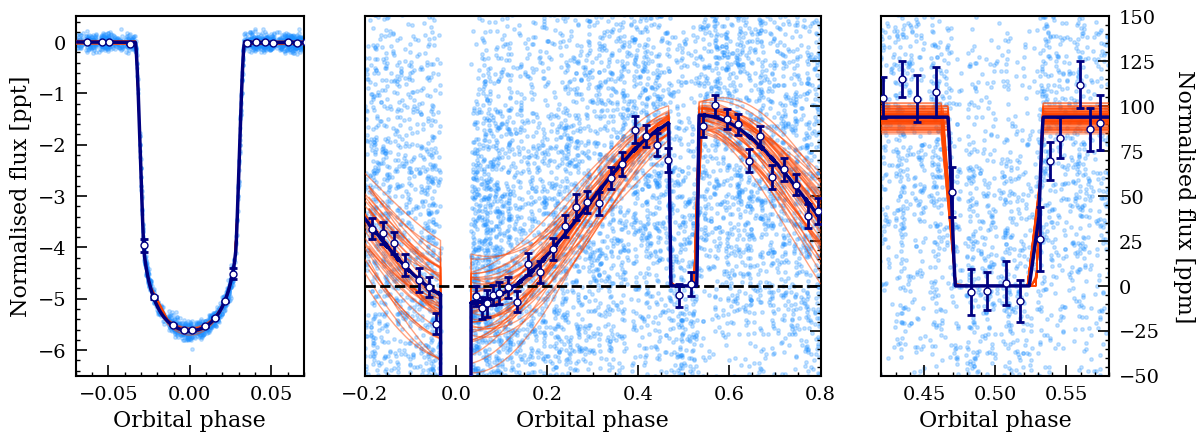

In [10]:
fig = plt.figure(figsize=(20/1.5, 7/1.5))
gs = gd.GridSpec( 1, 3, width_ratios=[1,2,1] )
## Transit, phase curve, and occultation (3 columns, 1 row)
ax1, ax2, ax3 = plt.subplot(gs[0]), plt.subplot(gs[1]), plt.subplot(gs[2])

# -------------------------------------------------------
#         Transits and phase curves
# -------------------------------------------------------
## To save the all detrended models and data so that we can calculated binned data points
all_phases_tra_det, all_models_tra_det, all_data_tra_det = np.array([]), np.array([]), np.array([])

for i in ['CHEOPS701', 'CHEOPS702']:
    ## Transits
    ### Median model
    ax1.errorbar(detrended_phs_all_ins[i], ( detrended_data_all_ins[i] - 1. ) * 1e3, fmt='.', alpha=0.25, color='dodgerblue', zorder=1)
    ### Random models
    for rand in range(20):
        ax1.plot(detrended_phs_all_ins[i], ( detrended_rand_models_all_ins[i][rand,:] - 1. ) * 1e3, color='orangered', alpha=0.5, lw=1., zorder=25)

    ## Phase curve
    ### Median model
    ax2.errorbar(detrended_phs_all_ins[i], ( detrended_data_all_ins[i] - 1. ) * 1e6, fmt='.', alpha=0.25, color='dodgerblue', zorder=1)
    ### Random models
    for rand in range(20):
        ax2.plot(detrended_phs_all_ins[i], ( detrended_rand_models_all_ins[i][rand,:] - 1. ) * 1e6, color='orangered', alpha=0.5, lw=1., zorder=25)

    ## Saving all detrended phases and data together
    all_phases_tra_det = np.hstack(( all_phases_tra_det, detrended_phs_all_ins[i] ))
    all_models_tra_det = np.hstack(( all_models_tra_det, ( detrended_models_all_ins[i] - 1. ) * 1e3 ))
    all_data_tra_det = np.hstack(( all_data_tra_det, ( detrended_data_all_ins[i] - 1. ) * 1e3 ))

# ----------- Calculating binned data
idx_phases = np.argsort( all_phases_tra_det )
## For transits
bphs_tra, bdata_tra, berrs_tra = juliet.utils.bin_data(x=all_phases_tra_det[idx_phases], y=all_data_tra_det[idx_phases], n_bin=100)
## For phase curves
bphs_pc, bdata_pc, berrs_pc = juliet.utils.bin_data(x=all_phases_tra_det[idx_phases], y=all_data_tra_det[idx_phases], n_bin=200)

# ----------- Plotting binned data and full median model
## For transits
ax1.plot(all_phases_tra_det[idx_phases], all_models_tra_det[idx_phases], color='navy', lw=2.5, zorder=50)
ax1.errorbar(bphs_tra, bdata_tra, yerr=berrs_tra, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
## For phase curves
ax2.plot(all_phases_tra_det[idx_phases], all_models_tra_det[idx_phases]*1e3, color='navy', lw=2.5, zorder=50)
ax2.errorbar(bphs_pc, bdata_pc*1e3, yerr=berrs_pc*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)

# ------------ x/y labels, limits etc
## For transits
ax1.set_xlim([ -0.07, 0.07 ])
ax1.set_ylim([ -6.5, 0.5])

ax1.set_xlabel('Orbital phase')
ax1.set_ylabel('Normalised flux [ppt]')

## For phase curves
ax2.axhline(0., ls='--', color='k', zorder=25)
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position('right')
ax2.yaxis.set_major_formatter(plt.NullFormatter())

ax2.set_xlim([ -0.2, 0.8 ])
ax2.set_ylim([ -50, 150 ])

ax2.set_xlabel('Orbital phase')

# -------------------------------------------------------
#                Occultations
# -------------------------------------------------------
## To save the all detrended models and data so that we can calculated binned data points
all_phases_occ_det, all_models_occ_det, all_data_occ_det = np.array([]), np.array([]), np.array([])

for i in ['CHEOPS201', 'CHEOPS202', 'CHEOPS203', 'CHEOPS204']:
    # Occultation
    ## Median model
    ax3.errorbar(detrended_phs_all_ins[i], ( detrended_data_all_ins[i] - 1. ) * 1e6, fmt='.', alpha=0.25, color='dodgerblue', zorder=1)
    ## Random models
    for rand in range(20):
        ax3.plot(detrended_phs_all_ins[i], ( detrended_rand_models_all_ins[i][rand,:] - 1. ) * 1e6, color='orangered', alpha=0.5, lw=1., zorder=25)
    
    ## Saving all detrended phases and data together
    all_phases_occ_det = np.hstack(( all_models_occ_det, detrended_phs_all_ins[i] ))
    all_models_occ_det = np.hstack(( all_models_occ_det, ( detrended_models_all_ins[i] - 1. ) * 1e3 ))
    all_data_occ_det = np.hstack(( all_data_occ_det, ( detrended_data_all_ins[i] - 1. ) * 1e6 ))

# ----------- Calculating binned data
idx_phases = np.argsort(all_phases_occ_det)
bphs_occ, bdata_occ, berrs_occ = juliet.utils.bin_data(x=all_phases_occ_det[idx_phases], y=all_data_occ_det[idx_phases], n_bin=50)

# ----------- Plotting binned data and full median model
ax3.plot(all_phases_occ_det[idx_phases], all_models_occ_det[idx_phases]*1e3, ls='-', color='navy', lw=2.5, zorder=50)
ax3.errorbar(bphs_occ, bdata_occ, yerr=berrs_occ, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)

# ------------ x/y labels, limits etc
ax3.set_xlim([0.42, 0.58])
ax3.set_ylim([-50, 150])

ax3.set_xlabel('Orbital phase')
ax3.set_ylabel('Normalised flux [ppm]', rotation=270, labelpad=25)

ax3.yaxis.tick_right()
ax3.yaxis.set_label_position('right')

Alright, we have a good transit, phase curve and occultation fitting it seems. The light blue and dark blue open data points are the original un-binned and binned data points, respectively. The blue solid line shows the median fitted planetary model, while the orange lines demonstrate the models calculated from the randomly selected posteriors. These random model demonstrate the uncertainty in the fitted model. The dashed black line in the middle panel gives the baseline flux level, which is set to the flux level during occultation, i.e., stellar flux. The left and middle panels show the transit and phase curve model+data from CHEOPS visits 701 and 702, while the right panel shows the occultation model+data from CHEOPS visits 201 to 204.

The blue and orange lines in the right panel seems to be broken -- that is because of gaps in the data, but otherwise everything is fine!

**There is one caveat to the phase curve fitting in `juliet`.** When we have only a partial phase curve, or occultation-only data without transits, we will naturally not give priors on the limb-darkening coefficients. In this case, `juliet` will **not** fit a phase curve model to this data by default. For example, in the above case, CHEOPS visits 201 to 204 only had occultation data, so we did not provide limb-darkening coefficients for these visits (which makes sense) -- therefore, `juliet` only fitted an occultation model to these visits, even though we specified the other phase curve parameters for every visits including these four. You can see this in fairly flat out-of-occultation model in the right panel of the above figure. `juliet` fitted occultation model only because we provided a prior on `fp_p1`. When `juliet` saw `fp_p1` prior, it thought that there is occultation model to be fitted to CHEOPS visits 201 to 204. But if we had not provided `fp_p1` prior, e.g., if we were trying to fit other phase curve models, then `juliet` would not have fitted any planetary model to this data.

This is done on purpose in `juliet`: for instance, if we only have partial phase curves, and none of them cover the near-transit phases, then there is no way to constrain night-side emission from the planet. This means that we cannot constrain one or more phase curve parameters properly for this case. To avoid this, `juliet` will not fit the full phase curve models to partial phase curves or occultation-only data, by default.

However, there could a case, where we have more than one partial phase curves, which collectively covers the full phase range. For example, in our case, even though the CHEOPS visits 201 to 204 only have occultations, together with visits 701 and 702, we have the full phase range. In this case, we may want to fit the full phase curve model even to the occultation-only visits. Then there is a work-around to this. In order to fit the full phase curve model to occultation-only visits (or partial phase curves), we can provide limb-darkening coefficients to these occultation-only visits. For example, instead of providing priors on `q1_CHEOPS701_CHEOPS701`, we can provide priors on `q1_CHEOPS201_CHEOPS202_CHEOPS203_CHEOPS204_CHEOPS701_CHEOPS702` -- if we do this, then `juliet` will think that CHEOPS visits 201 to 204 also have transits in them, and fit a full phase curve model. We will demonstrate this later in this notebook, when we try Lambertian phase curve fitting.

For now, we can calculate the occultation depth and night-side emission from the planet using the phase curve parameters. Occultation depth is simply `fp_p1` parameter, while the night-side emission can be computed from `fp_p1` and `C1_p1` (it is `fp_p1`-2*`C1_p1`). Let's plot their posteriors.

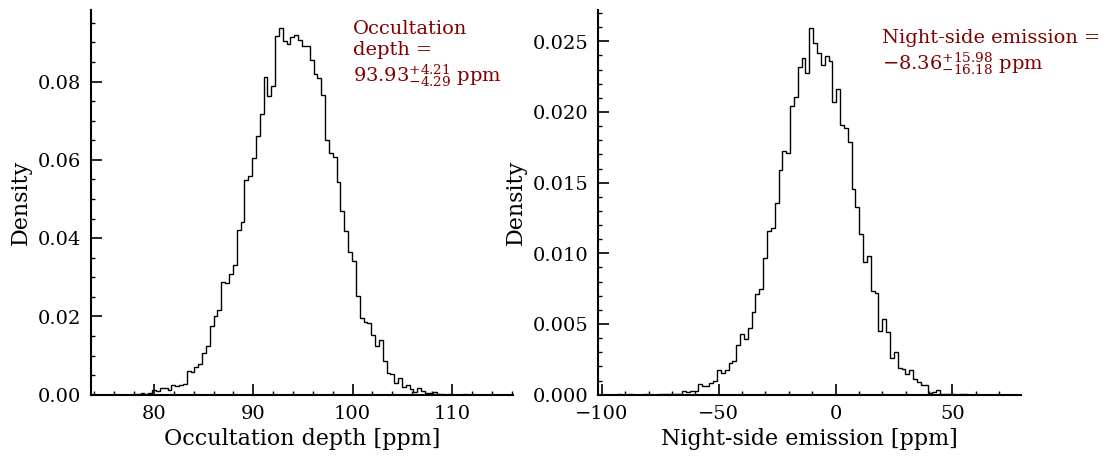

In [11]:
# Phase curve parameters
E = res.posteriors['posterior_samples']['fp_p1']
C1, D1 = res.posteriors['posterior_samples']['C1_p1'], res.posteriors['posterior_samples']['D1_p1']
C2, D2 = np.zeros(len(C1)), np.zeros(len(C1))

fp_day, fp_night = E, E-2*C1

# Computing the confidence intervals for the eccentricity and occultation depth
qua_fp_day = juliet.utils.get_quantiles(fp_day*1e6)
fp_day_med, fp_day_up, fp_day_lo = qua_fp_day[0], qua_fp_day[1]-qua_fp_day[0], qua_fp_day[0]-qua_fp_day[2]

qua_fp_night = juliet.utils.get_quantiles(fp_night*1e6)
fp_night_med, fp_night_up, fp_night_lo = qua_fp_night[0], qua_fp_night[1]-qua_fp_night[0], qua_fp_night[0]-qua_fp_night[2]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

axs[0].hist(fp_day*1e6, color='k', bins=100, histtype='step', density=True);
axs[0].text(100, 0.08, 'Occultation\ndepth = \n${' + str(np.around(fp_day_med,2)) + '}_{-' + str(np.around(fp_day_lo,2)) + '}^{+' + str(np.around(fp_day_up,2)) + '}$ ppm', color='maroon', fontsize=14)
axs[0].set_xlabel('Occultation depth [ppm]')
axs[0].set_ylabel('Density')

axs[1].hist(fp_night*1e6, bins=100, color='k', histtype='step', density=True);
axs[1].text(20, 0.023, 'Night-side emission =\n${' + str(np.around(fp_night_med,2)) + '}_{-' + str(np.around(fp_night_lo,2)) + '}^{+' + str(np.around(fp_night_up,2)) + '}$ ppm', color='maroon', fontsize=14)
axs[1].set_xlabel('Night-side emission [ppm]')
axs[1].set_ylabel('Density')

sns.despine()

The value of occultation depth is consistent with its value reported in [Deline et al. (2022)](https://ui.adsabs.harvard.edu/abs/2022A%26A...659A..74D/abstract), which is great! [Deline et al. (2022)](https://ui.adsabs.harvard.edu/abs/2022A%26A...659A..74D/abstract) fixed night-side emission to zero, which is also what we found.

There is an advantage of using [Cowan & Agol (2008)](https://ui.adsabs.harvard.edu/abs/2008ApJ...678L.129C/abstract) phase curve model, which is that we can invert the phase curve model to find the 2D brightness distribution of the planet, given certain assumptions. Phase curves typically constrain the longitudinal brightness variations, while the latitudinal brightness remains poorly constrained. So, if we want to build a 2D brightness map, then we have to make certain assumptions. For instance, we cab assume that the planet has a negligible brightness at the poles and that the planet's brightness varies sinusoidally along the latitudes (see, [Patel et al. 2025](https://ui.adsabs.harvard.edu/abs/2025arXiv251205175P/abstract) and references therein). Under these assumptions, planet's brightness, $I$, as a function of longitude ($\phi$) and latitude ($\theta$) can be calculated as,

$$I(\phi,\theta) = \frac{3}{4} \cdot J(\phi)\cdot \sin{(\theta + \pi/2)}.$$

where, $J(\phi)$ is integrated brightness variation along longitudes, and, can be defined as,

$$J(\phi) = A_0 + A_1\cos{\phi} + B_1\sin{\phi} + A_2\cos{2\phi} + B_2\sin{2\phi}.$$

The coefficients $A_0$, $A_1$, $A_2$, $B_1$, and $B_2$ are related to phase curve coefficients as,

\begin{equation*}
    \begin{split}
        A_0 &= (E - C_1 - C_2)/2,\\ 
        A_1 &= 2C_1/\pi,\\
        B_1 &= -2D_1/\pi,\\
        A_2 &= 3C_2/2,\\
        B_2 &= -3D_2/2.
    \end{split}
\end{equation*}

Let's use this formulation to find the brightness map of the planet.

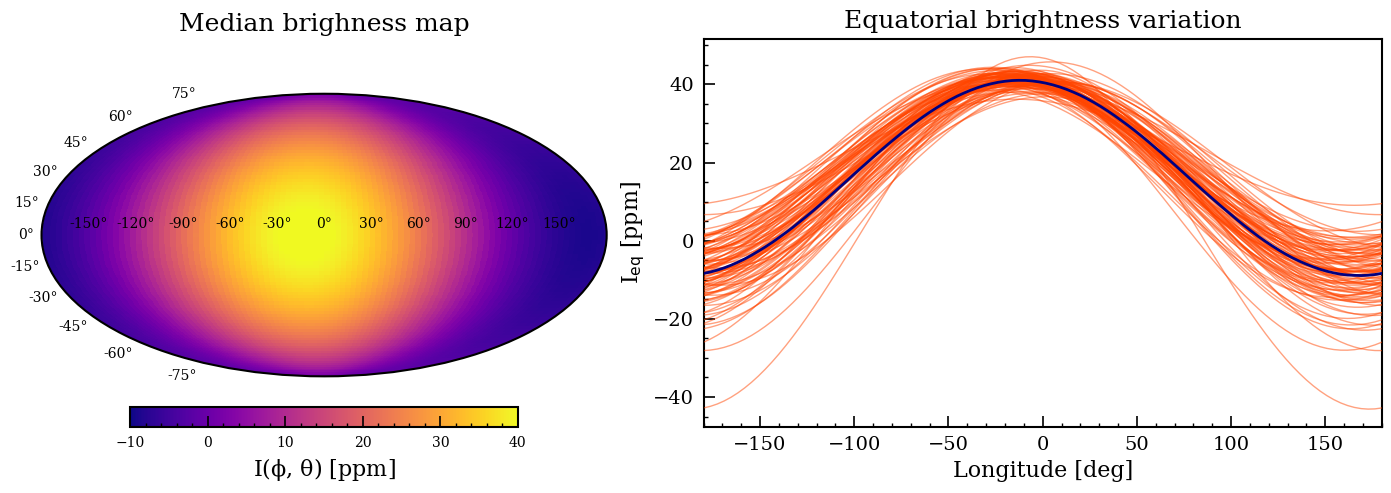

In [12]:
# Computing A and B coefficients from the phase curve parameters
A0 = (E - C1 - C2) / 2
A1 = 2 * C1 / np.pi
B1 = -2 * D1 / np.pi
A2 = 3 * C2 / 2
B2 = -3 * D2 / 2

# Defining the longitude-latitude grid
phi_ang = np.linspace(-np.pi, np.pi, 100)            # Longitude grid
theta_ang = np.linspace(-np.pi/2, np.pi/2, 101)      # Latitude grid
theta2d, phi2d = np.meshgrid(theta_ang, phi_ang)     # 2D meshgrid of latitude-longitude

## Calculating J_phi
J_phi = A0[:,None] + A1[:,None]*np.cos(phi_ang[None,:]) + B1[:,None]*np.sin(phi_ang[None,:]) +\
        A2[:,None]*np.cos(2*phi_ang[None,:]) + B2[:,None]*np.sin(2*phi_ang[None,:])

## 2D brightness variations (for each posterior samples)
I_phi_theta = 3. * np.sin(theta_ang[None,None,:] + np.pi/2) * J_phi[:,:,None] / 4.

## Median 2D brightness distribution
med_I_map = np.nanmedian(I_phi_theta*1e6, axis=0)


# --------------------------------------------------------------------------
#        Plotting the median brightness map and 
#        Equatorial brightness variation
# --------------------------------------------------------------------------
# larger figure and GridSpec to give the map more room
fig = plt.figure(figsize=(14, 5))
gs = gd.GridSpec(1, 2, width_ratios=[1, 1.2])

# left: mollweide map (bigger)
ax0 = fig.add_subplot(gs[0], projection='mollweide')
cax = ax0.pcolormesh(phi2d, theta2d, med_I_map, shading='auto')
cax.set_clim([-10, 40])
# set tick positions in RADIANS and readable labels in degrees
deg_ticks = np.array([-150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150])
ax0.set_xticks(np.deg2rad(deg_ticks))
ax0.tick_params(labelsize=10)
# smaller horizontal colorbar under the map (use fraction to reduce its size)
cb = fig.colorbar(cax, ax=ax0, label=r'I($\phi$, $\theta$) [ppm]', orientation='horizontal', fraction=0.05, pad=0.08)
cb.ax.tick_params(labelsize=10)
ax0.set_title('Median brighness map', pad=45)

# right: longitude cut/profile
ax1 = fig.add_subplot(gs[1])
ax1.plot(np.rad2deg(phi_ang), med_I_map[:,50], color='navy', lw=2., zorder=100)
for i in range(100):
    ax1.plot(np.rad2deg(phi_ang), I_phi_theta[np.random.randint(0,J_phi.shape[0]),:,50]*1e6, alpha=0.5, color='orangered', lw=1., zorder=10)

ax1.set_xlim([-180., 180.])
ax1.set_xlabel('Longitude [deg]')
ax1.set_ylabel(r'I$_\text{eq}$ [ppm]')
ax1.set_title('Equatorial brightness variation')

plt.tight_layout()

The left panel shows the median brightness map, and the right panel shows the equatorial brightness variation as a function of longitude. The blue and orange lines in the right panels depict the median brightness variation and the brightness calculated from the randomly selected posteriors, respectively. As can be seen, we can constrain brightness of all dayside longitudes quite properly, but some of the nightside longitudes are not constrained properly.

If we believe that we only observe thermal emission from the planet in CHEOPS bandpass, then we can invert the calculated brightness of the planet to find its brightness temperature map in CHEOPS bandpass using Planck's law. This is particularly important because it lets us understand the thermal structure of the planet.

However, it is possible that the thermal emission is not the sole source of emission in any wide-band photoemetric bandpass. We can get contamination from reflected light given the stellar and planetary effective temperature. Indeed, [Deline et al. (2022)](https://ui.adsabs.harvard.edu/abs/2022A%26A...659A..74D/abstract) fitted both thermal and reflected emission model to the CHEOPS data. For reflected light model, they used a phase curve model from a Lambertian sphere. `juliet` can also fit a model of the reflected light from a Lambertian sphere to the data. This model is defined by one single parameter, geometric albedo. We need to provide a prior on geometric albedo, `aglambert_p1`, to activate this model. However, we do not want to fit _only_ Lambertian phase curve model to the data because, as shown by [Deline et al. (2022)](https://ui.adsabs.harvard.edu/abs/2022A%26A...659A..74D/abstract), it would require unphysically large geometric albedo to produce observed occultation depth. Much likely possibility is that we are observing both thermal emission and reflected light in CHEOPS bandpass. Therefore, in addition to the Lambertian phase curve model, we want to fit a model that can model the thermal emission, for example, [Cowan & Agol (2008)](https://ui.adsabs.harvard.edu/abs/2008ApJ...678L.129C/abstract) phase curve model. In `juliet`, it is possible to fit more than one phase curve models to the data -- `juliet` will add all defined models before generating a total model. It can be any number of supported phase curve models. The user simply needs to provide appropriate priors for the phase curve models. Please note that `juliet` will _not_ check whether the requested total model is physical; it is user's responsibility to check that the phase curve model that the user wants to fit to the data is physical.

In our example, we will add two phase curve models together to generate a total phase curve model: [Cowan & Agol (2008)](https://ui.adsabs.harvard.edu/abs/2008ApJ...678L.129C/abstract) phase curve model and Lambertian model. The former will try to fit the thermal emission, while the later will model the reflected light. To do this, we will provide a prior on `aglambert_p1` in addition to the priors on [Cowan & Agol (2008)](https://ui.adsabs.harvard.edu/abs/2008ApJ...678L.129C/abstract) phase curve parameters, `fp_p1`, `C1_p1`, `D1_p1`, `C2_p1`, and `D2_p1`.

Furthermore, we now want to fit a full phase curve model even to occultation-only observations. As mentioned before, we can do this by setting limb-darkening coefficients even for these observations, even though there is no transit in those dataset. Doing so would make `juliet` fit a full phase curve model to occultation-only observations, instead of just occultation model without any phase curve variation.

Alright, so let's set up priors. We only need to change planetary priors; we can re-use the instrumental, linear, and GP priors from our previous analysis.

In [13]:
# Planetary parameters
par_P = ['P_p1', 't0_p1', 'p_p1', 'b_p1', 'q1_' + '_'.join(instruments), 'q2_' + '_'.join(instruments), 'rho', 'ecc_p1', 'omega_p1']
dist_P = ['normal', 'normal', 'uniform', 'normal', 'uniform', 'uniform', 'normal', 'fixed', 'fixed']
hyper_P = [[per, per_err], [tc, tc_err], [0., 1.], [b, 3*b_err], [0., 1.], [0., 1.], [rho, rho_err], 0., 90.]

## Phase curve parameters
### Cowan & Agol (2008) model parameters
par_pc_ca8 = ['fp_p1', 'C1_p1', 'D1_p1', 'C2_p1', 'D2_p1']
dist_pc_ca8 = ['uniform', 'uniform', 'uniform', 'fixed', 'fixed']
hyper_pc_ca8 = [[0., 200.e-6], [-1., 1.], [-1., 1.], 0., 0.]
### Lambertian model parameter
par_pc_lambert = ['aglambert_p1']
dist_pc_lambert = ['uniform']
hyper_pc_lambert = [[0, 2/3]]

# Total priors
par_lam = par_P + par_pc_ca8 + par_pc_lambert + par_ins + par_lin + par_gp
dist_lam = dist_P + dist_pc_ca8 + dist_pc_lambert + dist_ins + dist_lin + dist_gp
hyper_lam = hyper_P + hyper_pc_ca8 + hyper_pc_lambert + hyper_ins + hyper_lin + hyper_gp

priors_lam = juliet.utils.generate_priors(params=par_lam, dists=dist_lam, hyperps=hyper_lam)

# Output folder
pout = os.getcwd() + '/Analysis/CA08_Lambert'

And, `juliet` fitting:

In [14]:
# Juliet fitting
data_lam = juliet.load(priors=priors_lam, t_lc=tim, y_lc=fl, yerr_lc=fle,\
                   GP_regressors_lc=gp_pars, linear_regressors_lc=lin_pars, out_folder=pout)
res_lam = data_lam.fit(sampler='dynamic_dynesty', nthreads=14, light_travel_delay=True, stellar_radius=2.365)

Detected dynamic_dynesty sampler output files --- extracting from /Users/jaspa/Documents/Codes/juliet-examples/Analysis/CA08_Lambert/_dynesty_DNS_posteriors.pkl


We now want to plot the fitted models, so we first need to calculate all models and detrend the data using those models:

In [15]:
# Let's create dicts to save all models and data for each instruments
## Detrended and binned data
detrended_phs_all_ins, detrended_data_all_ins, detrended_errs_all_ins = {}, {}, {}
### Detrended models
detrended_models_all_ins, detrended_rand_models_all_ins = {}, {}

# Planetary parameters
P_post = np.nanmedian( res_lam.posteriors['posterior_samples']['P_p1'] )
tc_post = np.nanmedian( res_lam.posteriors['posterior_samples']['t0_p1'] )

for ins in range(len(instruments)):
    instrument = instruments[ins]
    print('Working on ' + str(instrument) + '...')
    # --------------------------------------------
    #    Some planetary models
    # --------------------------------------------
    ## Mflux and sigma_w (white noise)
    mflx = res_lam.posteriors['posterior_samples']['mflux_' + instrument]
    sigw = np.nanmedian(res_lam.posteriors['posterior_samples']['sigma_w_' + instrument] * 1e-6)

    # --------------------------------------------
    #    Extracting all models
    # --------------------------------------------
    # Creating all models
    model = res_lam.lc.evaluate(instrument, nsamples=5000, return_err=True, return_components=True, return_samples=True)
    ## Saving all models
    all_models = res_lam.lc.model[instrument]

    # --------------------------------------------
    #    Detrended data
    # --------------------------------------------
    ## GP model
    try:
        gp_median_model = all_models['GP']
    except:
        gp_median_model = np.zeros(len(tim[instrument]))

    ## Linear model
    try:
        lin_median_model = model[-1]['lm']
    except:
        lin_median_model = np.zeros( len( tim[instrument] ) )

    ## F1 and F2 factors (F2=0 for this case since mdilution is fixed to 1)
    ## See, juliet paper to find their meanings
    F1 = np.nanmedian( 1 / ( 1 + mflx ) )
    F2 = 0.

    # Orbital phases
    phases = juliet.utils.get_phases(t=tim[instrument], P=P_post, t0=tc_post, phmin=0.8)
    ## Sorting indices according to orbital phases
    idx_phs = np.argsort(phases)
    detrended_phs_all_ins[instrument] = phases[idx_phs]

    # Detrended data and errors
    detrended_data_all_ins[instrument] = ( ( fl[instrument] - gp_median_model - lin_median_model ) / F1 )[idx_phs]
    detrended_errs_all_ins[instrument] = ( np.sqrt( fle[instrument]**2 + sigw**2 ) )[idx_phs]

    # --------------------------------------------
    #    Detrended models
    # --------------------------------------------
    # Detrended model (we only want to see changes due to planetary parameters so we will fix other params)
    post_samps_new = res_lam.posteriors['posterior_samples'].copy()
    for i in post_samps_new.keys():
        if ( i[0:5] == 'mflux' ) or ( i[0:9] == 'mdilution' ) or ( i[0:5] == 'theta' ) or ( i[0:2] == 'GP' ):
            post_samps_new[i] = np.zeros(len(post_samps_new[i]))

    planet_only_models = res_lam.lc.evaluate(instrument, nsamples=5000, return_err=True, parameter_values=post_samps_new,\
                                         return_components=True, return_samples=True, evaluate_transit=True)

    # Detrended median model
    detrended_models_all_ins[instrument] = planet_only_models[1][idx_phs]
    ## Random models to show uncertainties
    sample_pl_models = planet_only_models[0][:, idx_phs]
    idx_nsamps_pl = np.random.choice( np.arange(sample_pl_models.shape[0]), size=100, replace=False)
    detrended_rand_models_all_ins[instrument] = sample_pl_models[idx_nsamps_pl, :]

    print('Done!!')

Working on CHEOPS201...
Done!!
Working on CHEOPS202...
Done!!
Working on CHEOPS203...
Done!!
Working on CHEOPS204...
Done!!
Working on CHEOPS701...
Done!!
Working on CHEOPS702...
Done!!


Now, let's plot the detrended data along with the planetary model:

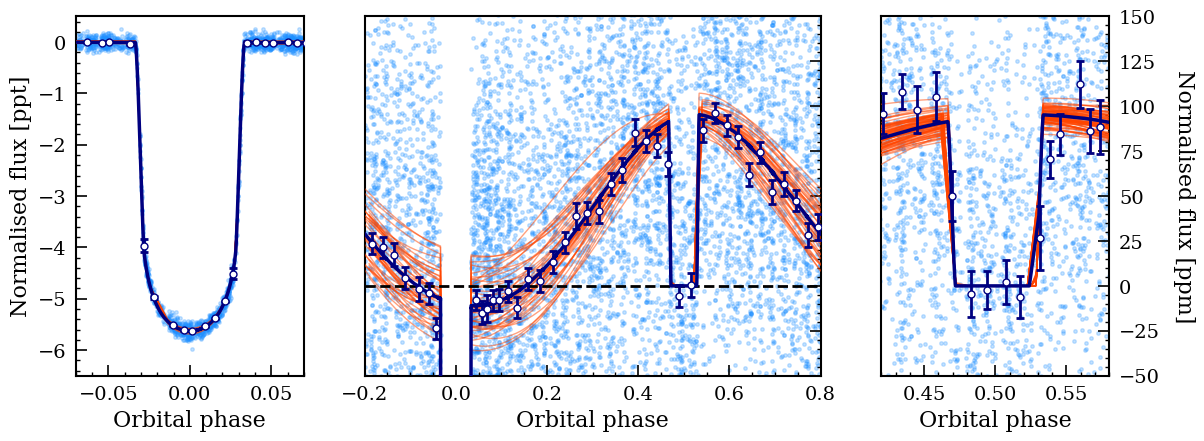

In [16]:
fig = plt.figure(figsize=(20/1.5, 7/1.5))
gs = gd.GridSpec( 1, 3, width_ratios=[1,2,1] )
## Transit, phase curve, and occultation (3 columns, 1 row)
ax1, ax2, ax3 = plt.subplot(gs[0]), plt.subplot(gs[1]), plt.subplot(gs[2])

# -------------------------------------------------------
#         Transits and phase curves
# -------------------------------------------------------
## To save the all detrended models and data so that we can calculated binned data points
all_phases_tra_det, all_models_tra_det, all_data_tra_det = np.array([]), np.array([]), np.array([])

for i in ['CHEOPS701', 'CHEOPS702']:
    ## Transits
    ### Median model
    ax1.errorbar(detrended_phs_all_ins[i], ( detrended_data_all_ins[i] - 1. ) * 1e3, fmt='.', alpha=0.25, color='dodgerblue', zorder=1)
    ### Random models
    for rand in range(20):
        ax1.plot(detrended_phs_all_ins[i], ( detrended_rand_models_all_ins[i][rand,:] - 1. ) * 1e3, color='orangered', alpha=0.5, lw=1., zorder=25)

    ## Phase curve
    ### Median model
    ax2.errorbar(detrended_phs_all_ins[i], ( detrended_data_all_ins[i] - 1. ) * 1e6, fmt='.', alpha=0.25, color='dodgerblue', zorder=1)
    ### Random models
    for rand in range(20):
        ax2.plot(detrended_phs_all_ins[i], ( detrended_rand_models_all_ins[i][rand,:] - 1. ) * 1e6, color='orangered', alpha=0.5, lw=1., zorder=25)

    ## Saving all detrended phases and data together
    all_phases_tra_det = np.hstack(( all_phases_tra_det, detrended_phs_all_ins[i] ))
    all_models_tra_det = np.hstack(( all_models_tra_det, ( detrended_models_all_ins[i] - 1. ) * 1e3 ))
    all_data_tra_det = np.hstack(( all_data_tra_det, ( detrended_data_all_ins[i] - 1. ) * 1e3 ))

# ----------- Calculating binned data
idx_phases = np.argsort( all_phases_tra_det )
## For transits
bphs_tra, bdata_tra, berrs_tra = juliet.utils.bin_data(x=all_phases_tra_det[idx_phases], y=all_data_tra_det[idx_phases], n_bin=100)
## For phase curves
bphs_pc, bdata_pc, berrs_pc = juliet.utils.bin_data(x=all_phases_tra_det[idx_phases], y=all_data_tra_det[idx_phases], n_bin=200)

# ----------- Plotting binned data and full median model
## For transits
ax1.plot(all_phases_tra_det[idx_phases], all_models_tra_det[idx_phases], color='navy', lw=2.5, zorder=50)
ax1.errorbar(bphs_tra, bdata_tra, yerr=berrs_tra, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
## For phase curves
ax2.plot(all_phases_tra_det[idx_phases], all_models_tra_det[idx_phases]*1e3, color='navy', lw=2.5, zorder=50)
ax2.errorbar(bphs_pc, bdata_pc*1e3, yerr=berrs_pc*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)

# ------------ x/y labels, limits etc
## For transits
ax1.set_xlim([ -0.07, 0.07 ])
ax1.set_ylim([ -6.5, 0.5])

ax1.set_xlabel('Orbital phase')
ax1.set_ylabel('Normalised flux [ppt]')

## For phase curves
ax2.axhline(0., ls='--', color='k', zorder=25)
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position('right')
ax2.yaxis.set_major_formatter(plt.NullFormatter())

ax2.set_xlim([ -0.2, 0.8 ])
ax2.set_ylim([ -50, 150 ])

ax2.set_xlabel('Orbital phase')

# -------------------------------------------------------
#                Occultations
# -------------------------------------------------------
## To save the all detrended models and data so that we can calculated binned data points
all_phases_occ_det, all_models_occ_det, all_data_occ_det = np.array([]), np.array([]), np.array([])

for i in ['CHEOPS201', 'CHEOPS202', 'CHEOPS203', 'CHEOPS204']:
    # Occultation
    ## Median model
    ax3.errorbar(detrended_phs_all_ins[i], ( detrended_data_all_ins[i] - 1. ) * 1e6, fmt='.', alpha=0.25, color='dodgerblue', zorder=1)
    ## Random models
    for rand in range(20):
        ax3.plot(detrended_phs_all_ins[i], ( detrended_rand_models_all_ins[i][rand,:] - 1. ) * 1e6, color='orangered', alpha=0.5, lw=1., zorder=25)
    
    ## Saving all detrended phases and data together
    all_phases_occ_det = np.hstack(( all_models_occ_det, detrended_phs_all_ins[i] ))
    all_models_occ_det = np.hstack(( all_models_occ_det, ( detrended_models_all_ins[i] - 1. ) * 1e3 ))
    all_data_occ_det = np.hstack(( all_data_occ_det, ( detrended_data_all_ins[i] - 1. ) * 1e6 ))

# ----------- Calculating binned data
idx_phases = np.argsort(all_phases_occ_det)
bphs_occ, bdata_occ, berrs_occ = juliet.utils.bin_data(x=all_phases_occ_det[idx_phases], y=all_data_occ_det[idx_phases], n_bin=50)

# ----------- Plotting binned data and full median model
ax3.plot(all_phases_occ_det[idx_phases], all_models_occ_det[idx_phases]*1e3, ls='-', color='navy', lw=2.5, zorder=50)
ax3.errorbar(bphs_occ, bdata_occ, yerr=berrs_occ, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)

# ------------ x/y labels, limits etc
ax3.set_xlim([0.42, 0.58])
ax3.set_ylim([-50, 150])

ax3.set_xlabel('Orbital phase')
ax3.set_ylabel('Normalised flux [ppm]', rotation=270, labelpad=25)

ax3.yaxis.tick_right()
ax3.yaxis.set_label_position('right')

The fitting seems good! As before, the light blue points are the original un-binned data points, while the blue open circles are the binned data points. The solid blue and orange lines show the median fitted model, and the models computed from the randomly selected posteriors. The dashed line in the middle panel show the baseline flux level, which is set according to the flux during the occultation, i.e., the stellar flux. The left and middle panel have the data from the CHEOPS visits 701 and 702, which contain full phase curve observations. The right panel have the data from occultation-only CHEOPS visits 201, 202, 203, and 204. As you can see in the right panel, the out-of-occultation model is not flat - this is because we are not fitting the full phase curve model even to the occultation-only data.

Let's now make a corner plot of day-side emission ($F_p^d$), night-side emission ($F_p^n$), and geometric albedo ($A_g$) to check the posterior distributions of these parameters. We note here that the occultation depth (which gives the _total_ emission at the full phase) would be different from day-side emission (which gives the emission due to thermal emission as measured by [Cowan & Agol 2008](https://ui.adsabs.harvard.edu/abs/2008ApJ...678L.129C/abstract) model) in this case.

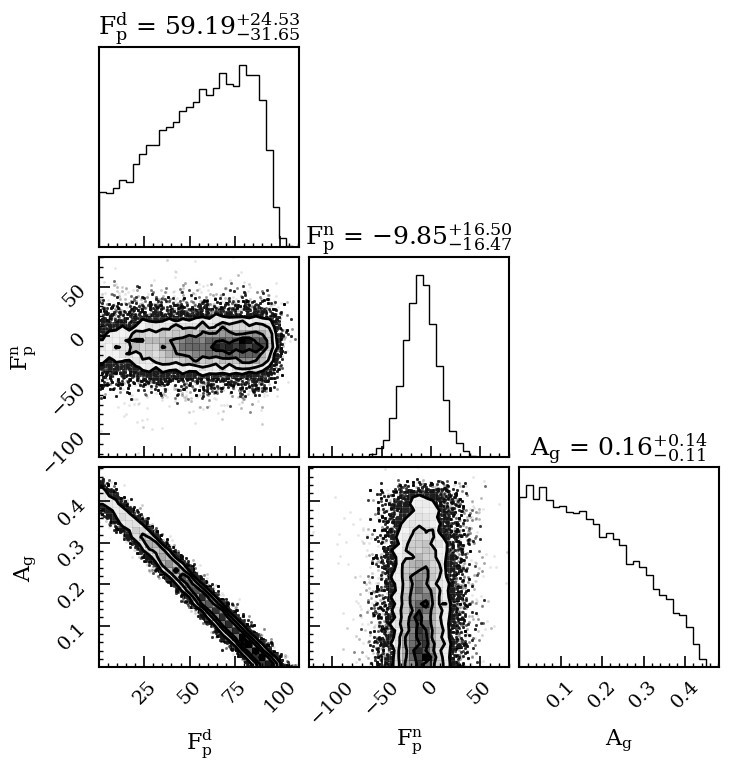

In [17]:
# Phase curve parameters
E = res_lam.posteriors['posterior_samples']['fp_p1']
C1, D1 = res_lam.posteriors['posterior_samples']['C1_p1'], res_lam.posteriors['posterior_samples']['D1_p1']
ag = res_lam.posteriors['posterior_samples']['aglambert_p1']

fp_day, fp_night = E, E-2*C1

data = np.transpose( np.vstack([ fp_day*1e6, fp_night*1e6, ag ]) )
labels = np.array([ r'F$_p^{d}$', r'F$_p^{n}$', r'$A_g$' ])

corner.corner(data=data, bins=30, labels=labels, show_titles=True);

The night-side emission is constrained properly and it is consistent with zero. However, now the day-side emission and geometric albedo of the planet is not well-constrained. That makes sense -- when the phase offset is consistent with zero, as in our case, it is extremely difficult to differentiate between the thermal emission and the reflected light emission. As a result, we are not able to constrain the day-side emission and geometric albedo. Further, the day-side emission and geometric albedo becomes strongly anti-correlated with each other, as can be seen from above plot.